In [1]:
from apeGmsh import apeGmsh, Part
from apeGmsh import FEMData
from apeGmsh.sections import W_solid
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
m1 = apeGmsh(model_name='beam_column', verbose=False)
m1.begin()

column = m1.sections.W_solid(bf=150, tf=20, h=300, tw=10, length=2000, label="column")

m1.model.selection.select_volumes().to_physical(name='pg_column')
m1.model.selection.select_points().to_physical(name='pg_points')

base = m1.model.geometry.add_point(x=0, y=0, z=0, lc=100, label='base')
top = m1.model.geometry.add_point(x=0, y=0, z=2000, lc=100, label='top')

m1.physical.add_curve(
    tags=[1],
    name='test'
)

# Constraints: couple ref points to end faces
m1.constraints.node_to_surface('base', column.labels.start_face)
m1.constraints.node_to_surface('top', column.labels.end_face)

# Define loads
m1.loads.point(
    target='top',
    force_xyz=[0,1000,0],
    moment_xyz=[0,0,0],
)

m1.mesh.sizing.set_global_size(100)
m1.mesh.generation.generate(dim=3)

fem = m1.mesh.queries.get_fem_data(remove_orphans=True)


m1.model.viewer()
m1.mesh.viewer()

m1.end()

In [3]:
# Build node table from FEM broker output
node = fem.nodes.get(target=['pg_column', 'base', 'top'])

nodes_df = pd.DataFrame(node.coords, columns=['x', 'y', 'z'])
nodes_df.insert(0, 'id', node.ids)

nodes_df

,id,x,y,z
0,1,-7.500000e+01,-150.000000,0.000000
1,2,-7.500000e+01,-150.000000,2000.000000
2,3,-7.500000e+01,-170.000000,0.000000
3,4,-7.500000e+01,-170.000000,2000.000000
4,5,-5.000000e+00,-150.000000,0.000000
...,...,...,...,...
641,644,2.273737e-17,-163.333333,833.333333
642,645,9.094947e-17,-163.333333,1433.333333
643,646,0.000000e+00,-160.000000,1350.000000
644,33,0.000000e+00,0.000000,0.000000


In [4]:
# Lets get the phantom nodes from the constrains
_pn = fem.nodes.constraints.phantom_nodes()
phantom_nodes_ids, phantom_nodes_coords = _pn.ids, _pn.coords

phantom_nodes_df = pd.DataFrame(phantom_nodes_coords)
phantom_nodes_df.insert(0, 'id', phantom_nodes_ids)

phantom_nodes_df

,id,0,1,2
0,647,-7.500000e+01,-150.0,0.0
1,648,-7.500000e+01,-170.0,0.0
2,649,-5.000000e+00,-150.0,0.0
3,650,-5.000000e+00,-170.0,0.0
4,651,-5.000000e+00,150.0,0.0
5,652,-5.000000e+00,170.0,0.0
6,653,-7.500000e+01,150.0,0.0
7,654,-7.500000e+01,170.0,0.0
8,655,5.000000e+00,170.0,0.0
9,656,5.000000e+00,150.0,0.0


In [5]:
element_id, element_conectivity = fem.elements.get(
    target='pg_column'
).resolve()

elements_df = pd.DataFrame(element_conectivity)
elements_df.insert(0, 'id', element_id)

elements_df

,id,0,1,2,3
0,99,352,58,57,368
1,100,43,42,356,374
2,101,96,97,384,362
3,102,372,40,60,354
4,103,351,38,37,386
...,...,...,...,...,...
1785,1884,187,188,90,261
1786,1885,189,88,89,260
1787,1886,89,88,189,94
1788,1887,89,188,189,260


In [6]:
# 1. Does ElementComposite iteration work without filtering?
for group in fem.elements:
    print(group.type_name, len(group))

# 2. Does the types property work?
print(fem.elements.types)

# 3. Does dim filter work?
print(list(fem.elements.get(dim=3)))

# 4. Finally, the element_type filter
print(list(fem.elements.get(element_type='tet4')))


line2 372
tri3 1488
tet4 1790
point1 34
[ElementTypeInfo('line2', code=1, dim=1, order=1, npe=2, count=372), ElementTypeInfo('tri3', code=2, dim=2, order=1, npe=3, count=1488), ElementTypeInfo('tet4', code=4, dim=3, order=1, npe=4, count=1790), ElementTypeInfo('point1', code=15, dim=0, order=0, npe=1, count=34)]
[ElementGroup('tet4', n=1790, npe=4)]
[ElementGroup('tet4', n=1790, npe=4)]


In [7]:
for nts in fem.nodes.constraints.node_to_surfaces():
    print(f"Master: {nts.master_node}")
    print(f"Slaves: {nts.slave_nodes}")
    print(f"Phantoms: {nts.phantom_nodes}")

    # Rigid beams: master → each phantom
    for pair in nts.rigid_link_records:
        print(f"Rigid link: master {pair.master_node} → slave {pair.slave_node}")
        #ops.rigidLink("beam", pair.master_node, pair.slave_node)

    # Equal DOFs: phantom → original slave
    for pair in nts.equal_dof_records:
        print(f"Equal DOF: master {pair.master_node} → slave {pair.slave_node}")
        #ops.equalDOF(pair.master_node, pair.slave_node, *pair.dofs)


Master: 33
Slaves: [1, 3, 5, 7, 9, 12, 13, 15, 17, 18, 19, 20, 25, 26, 29, 30, 339, 340, 343, 344, 508, 627]
Phantoms: [647, 648, 649, 650, 651, 652, 653, 654, 655, 656, 657, 658, 659, 660, 661, 662, 663, 664, 665, 666, 667, 668]
Rigid link: master 33 → slave 647
Rigid link: master 33 → slave 648
Rigid link: master 33 → slave 649
Rigid link: master 33 → slave 650
Rigid link: master 33 → slave 651
Rigid link: master 33 → slave 652
Rigid link: master 33 → slave 653
Rigid link: master 33 → slave 654
Rigid link: master 33 → slave 655
Rigid link: master 33 → slave 656
Rigid link: master 33 → slave 657
Rigid link: master 33 → slave 658
Rigid link: master 33 → slave 659
Rigid link: master 33 → slave 660
Rigid link: master 33 → slave 661
Rigid link: master 33 → slave 662
Rigid link: master 33 → slave 663
Rigid link: master 33 → slave 664
Rigid link: master 33 → slave 665
Rigid link: master 33 → slave 666
Rigid link: master 33 → slave 667
Rigid link: master 33 → slave 668
Equal DOF: master 647 

In [8]:
# 2. Rigid links
for master, slaves in fem.nodes.constraints.rigid_link_groups():
    for slave in slaves:
        print(f"Rigid link: master {master} → slave {slave}")
        #ops.rigidLink("beam", master, slave)

# 3. Equal DOFs
for pair in fem.nodes.constraints.equal_dofs():
    print(f"Equal DOF: master {pair.master_node} → slave {pair.slave_node} and pairs.dofs {pair.dofs}")
    #ops.equalDOF(pair.master_node, pair.slave_node, *pair.dofs)

Rigid link: master 33 → slave 647
Rigid link: master 33 → slave 648
Rigid link: master 33 → slave 649
Rigid link: master 33 → slave 650
Rigid link: master 33 → slave 651
Rigid link: master 33 → slave 652
Rigid link: master 33 → slave 653
Rigid link: master 33 → slave 654
Rigid link: master 33 → slave 655
Rigid link: master 33 → slave 656
Rigid link: master 33 → slave 657
Rigid link: master 33 → slave 658
Rigid link: master 33 → slave 659
Rigid link: master 33 → slave 660
Rigid link: master 33 → slave 661
Rigid link: master 33 → slave 662
Rigid link: master 33 → slave 663
Rigid link: master 33 → slave 664
Rigid link: master 33 → slave 665
Rigid link: master 33 → slave 666
Rigid link: master 33 → slave 667
Rigid link: master 33 → slave 668
Rigid link: master 34 → slave 669
Rigid link: master 34 → slave 670
Rigid link: master 34 → slave 671
Rigid link: master 34 → slave 672
Rigid link: master 34 → slave 673
Rigid link: master 34 → slave 674
Rigid link: master 34 → slave 675
Rigid link: ma

In [9]:
# fem.elements.get(element_type='tet4')

In [10]:
import openseespy.opensees as ops

ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 3)

# Define a time series for the analysis (required by OpenSees)
linear_time_series_tag = 1
ops.timeSeries('Linear', linear_time_series_tag)

# Solid column nodes (ndf=3)
for nid, xyz in fem.nodes.get(target=['pg_column']):
    ops.node(nid, *xyz)

# Reference points at base and top (ndf=6)
for nid, xyz in fem.nodes.get(target=['base', 'top']):
    ops.node(nid, *xyz, '-ndf', 6)

# Phantom nodes created by node_to_surface (ndf=6)
for nid, xyz in fem.nodes.constraints.phantom_nodes():
    ops.node(nid, *xyz, '-ndf', 6)

# Create nodal boundary conditions, natural and essential
base_ids = fem.nodes.get_ids(target='base')

for base_id in base_ids:
    ops.fix(base_id, 1, 1, 1, 1, 1, 1)

loads = fem.nodes.loads.by_kind('nodal')

# Load
load_pattern_tag = 1
ops.pattern('Plain', load_pattern_tag, linear_time_series_tag)

for load in loads:
    fx, fy, fz = load.force_xyz  or (0.0, 0.0, 0.0)
    mx, my, mz = load.moment_xyz or (0.0, 0.0, 0.0)
    ops.load(int(load.node_id), fx, fy, fz, mx, my, mz)

# Define the material and the elemnt creation
E = 2e5 # Young's modulus in MPa
nu = 0.3 # Poisson's ratio

# create a elastic isotropic material in OpenSees
material_tag = 1
ops.nDMaterial('ElasticIsotropic', material_tag, E, nu)

# create the tetrahedral elements in OpenSees
for group in fem.elements.get(element_type='tet4'):
    for eid, conn in group:
        ops.element('FourNodeTetrahedron', eid, *conn, material_tag)

# Create EqualDOF constraints for the phantom nodes
# equalDOF(rNodeTag, cNodeTag, *dofs)
# rigidLink(type, rNodeTag, cNodeTag)

for master, slaves in fem.nodes.constraints.rigid_link_groups():
    for slave in slaves:
        ops.rigidLink("beam", master, slave)

# 3. Equal DOFs
for pair in fem.nodes.constraints.equal_dofs():
    ops.equalDOF(pair.master_node, pair.slave_node, *pair.dofs)

# -----------------------------------------------------------------------------------------

# Analysis
ops.constraints('Penalty', 1e15, 1e15)
# ops.constraints('Transformation')
ops.numberer('RCM')
ops.system('UmfPack')
ops.test('NormDispIncr', 1.0e-6, 10)
ops.algorithm('Linear')
ops.integrator('LoadControl', 0.1)
ops.analysis('Static')


# --- LEGACY-API-MIGRATED ---
# Initialise per-step result containers (originally absent from
# this notebook).
top_ids = fem.nodes.get_ids(target='top')
monitored_ids = list(top_ids) + list(base_ids)
load_factor_history: list[float] = []
displacement_results = {int(_nid): [] for _nid in monitored_ids}
reactions_results    = {int(_nid): [] for _nid in monitored_ids}

for i in range(10):
    print(f"Step {i+1}")
    ok = ops.analyze(1)
    if ok != 0:
        print(f"  analysis failed at step {i+1}")
        break

    # Reactions must be recomputed each step before querying
    ops.reactions()

    load_factor_history.append(ops.getTime())

    for nid in monitored_ids:
        displacement_results[nid].append(ops.nodeDisp(int(nid)))
        reactions_results[nid].append(ops.nodeReaction(int(nid)))

Step 1
Step 2
Step 3
Step 4
Step 5


Step 6


Step 7


Step 8
Step 9


Step 10


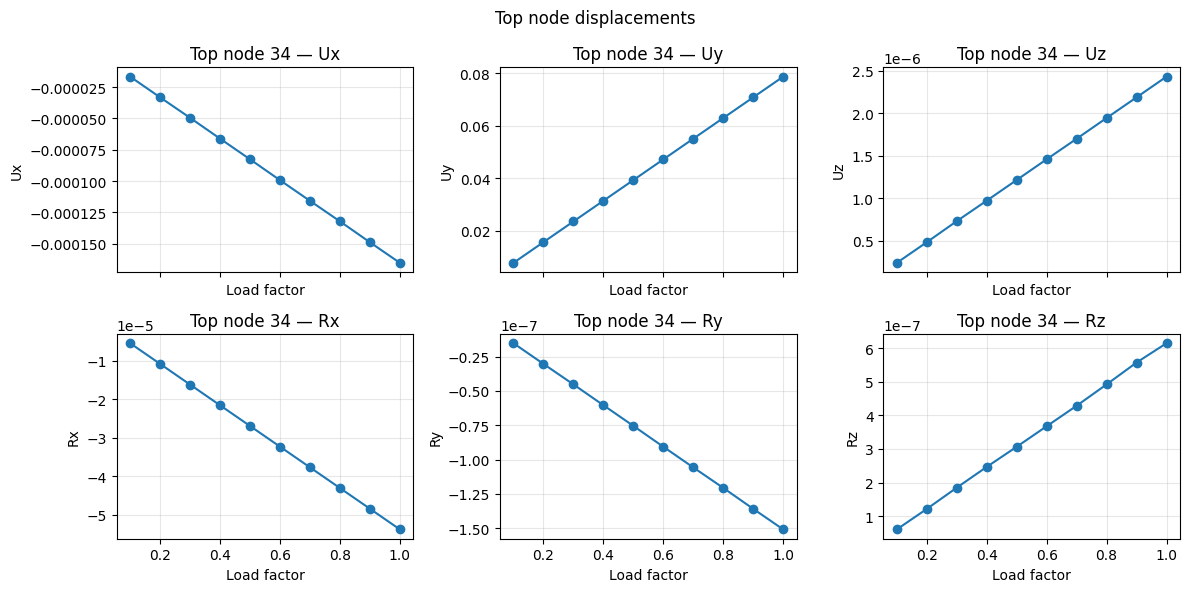

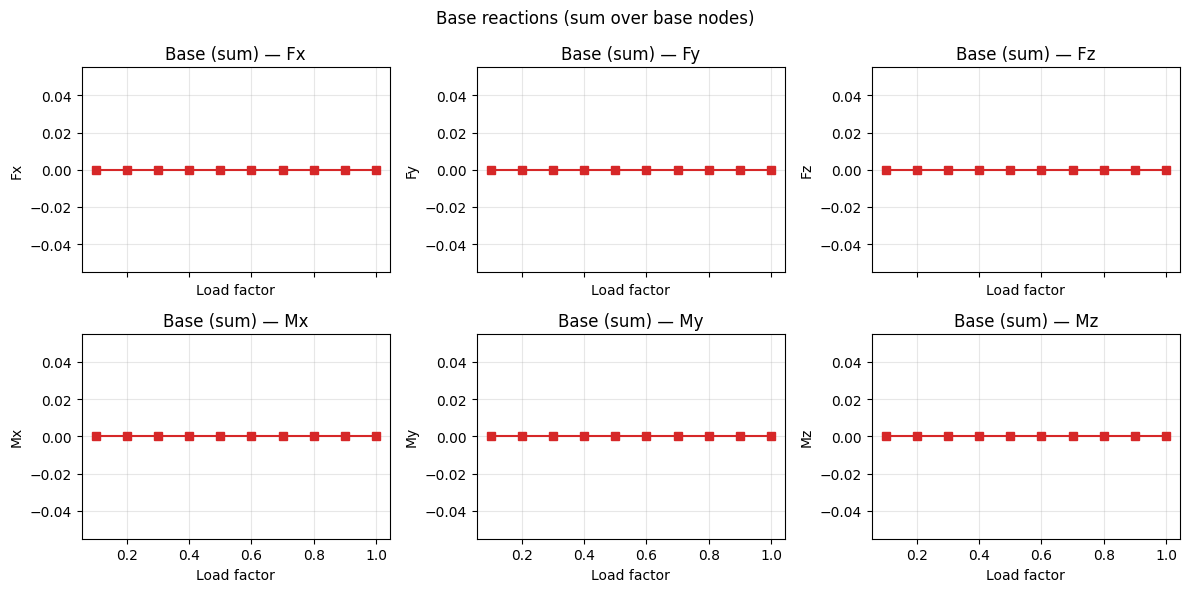

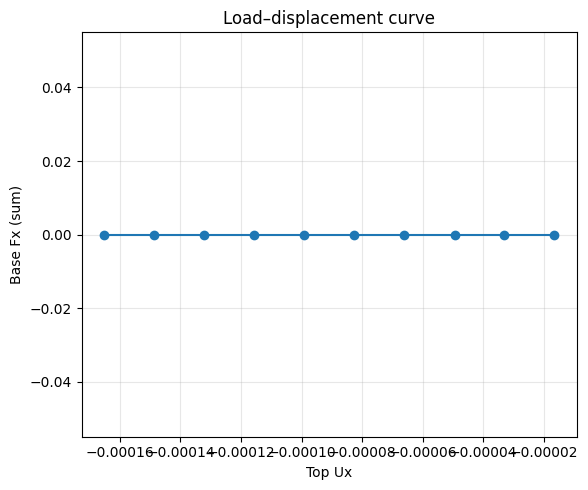

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Assemble arrays ---
lf = np.asarray(load_factor_history)                          # (nsteps,)

top_id = int(top_ids[0])                                      # assume single top node
top_disp = np.asarray(displacement_results[top_id])           # (nsteps, 6)

base_rxn = np.stack([np.asarray(reactions_results[int(n)])    # (nbase, nsteps, 6)
                     for n in base_ids])
base_sum = base_rxn.sum(axis=0)                               # (nsteps, 6) — summed over base nodes

dof_labels_force = ['Fx', 'Fy', 'Fz', 'Mx', 'My', 'Mz']
dof_labels_disp  = ['Ux', 'Uy', 'Uz', 'Rx', 'Ry', 'Rz']

# --- Figure 1: top node displacement vs load factor ---
fig1, axes1 = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for k, ax in enumerate(axes1.flat):
    ax.plot(lf, top_disp[:, k], marker='o')
    ax.set_title(f'Top node {top_id} — {dof_labels_disp[k]}')
    ax.set_xlabel('Load factor')
    ax.set_ylabel(dof_labels_disp[k])
    ax.grid(True, alpha=0.3)
fig1.suptitle('Top node displacements')
fig1.tight_layout()

# --- Figure 2: summed base reactions vs load factor ---
fig2, axes2 = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for k, ax in enumerate(axes2.flat):
    ax.plot(lf, base_sum[:, k], marker='s', color='C3')
    ax.set_title(f'Base (sum) — {dof_labels_force[k]}')
    ax.set_xlabel('Load factor')
    ax.set_ylabel(dof_labels_force[k])
    ax.grid(True, alpha=0.3)
fig2.suptitle('Base reactions (sum over base nodes)')
fig2.tight_layout()

# --- Figure 3: load–displacement curve (top disp vs base shear) ---
# Pick the DOF that matters for your loading — adjust index as needed
dof = 0  # 0=Ux, 1=Uy, 2=Uz
fig3, ax3 = plt.subplots(figsize=(6, 5))
ax3.plot(top_disp[:, dof], base_sum[:, dof], marker='o')
ax3.set_xlabel(f'Top {dof_labels_disp[dof]}')
ax3.set_ylabel(f'Base {dof_labels_force[dof]} (sum)')
ax3.set_title('Load–displacement curve')
ax3.grid(True, alpha=0.3)
fig3.tight_layout()

plt.show()

## 9. Capture results — manual + DomainCapture paths

Two ways to produce a native-HDF5 results file consumable by the
apeGmsh ``ResultsViewer``:

1. **Manual path** — query the live OpenSees domain post-analysis,
   open a ``NativeWriter``, and write nodal displacements yourself.
   Good for one-shot snapshots and post-hoc diagnostics.
2. **DomainCapture path** — declare what to capture with
   ``Recorders().nodes(...)``, hand the spec to a ``DomainCapture``
   context, and call ``cap.step(t=...)`` after each ``ops.analyze``
   (the helper does it for you). Scales to multi-stage, transient,
   modal, and multi-recorder runs.

Both produce a file that ``Results.from_native(path).viewer()`` can
open. The viewer launch is gated on ``APEGMSH_SKIP_VIEWER`` so this
notebook is safe to run under nbconvert / CI.


In [12]:
# --- EOS-WIRING-V1 ---
# Manual path: pull displacements off the live domain, write h5 yourself.
from pathlib import Path
import numpy as np
from apeGmsh.results.writers import NativeWriter

results_manual = Path("example_column_nodeToSurface_manual.h5")
if results_manual.exists():
    results_manual.unlink()

_n = len(fem.nodes.ids)
_ux = np.array([ops.nodeDisp(int(nid), 1) for nid in fem.nodes.ids])
_uy = np.array([ops.nodeDisp(int(nid), 2) for nid in fem.nodes.ids])
_uz = np.array([ops.nodeDisp(int(nid), 3) for nid in fem.nodes.ids])
_components = {
    "displacement_x": _ux.reshape(1, _n),
    "displacement_y": _uy.reshape(1, _n),
    "displacement_z": _uz.reshape(1, _n),
}

with NativeWriter(results_manual) as _nw:
    _nw.open(fem=fem)
    _sid = _nw.begin_stage(name="static", kind="static", time=np.array([1.0]))
    _nw.write_nodes(
        _sid, "partition_0",
        node_ids=np.asarray(fem.nodes.ids, dtype=np.int64),
        components=_components,
    )
    _nw.end_stage()

print(f"manual -> {results_manual} ({results_manual.stat().st_size/1024:.1f} KB)")


manual -> example_column_nodeToSurface_manual.h5 (454.3 KB)


In [13]:
# DomainCapture path: declarative recorders, capture during analyze.
from apeGmsh.solvers.Recorders import Recorders
from apeGmsh.results.capture._domain import DomainCapture

recs = Recorders()
recs.nodes(components="displacement")
recs.nodes(components="reaction_force")
spec = recs.resolve(fem, ndm=3, ndf=3)

results_capture = Path("example_column_nodeToSurface_capture.h5")
if results_capture.exists():
    results_capture.unlink()

with DomainCapture(spec, results_capture, fem, ndm=3, ndf=3) as cap:
    cap.begin_stage("run", kind="static")
    # --- copied from cell 9 ---
    import openseespy.opensees as ops

    ops.wipe()
    ops.model('basic', '-ndm', 3, '-ndf', 3)

    # Define a time series for the analysis (required by OpenSees)
    linear_time_series_tag = 1
    ops.timeSeries('Linear', linear_time_series_tag)

    # Solid column nodes (ndf=3)
    for nid, xyz in fem.nodes.get(target=['pg_column']):
        ops.node(nid, *xyz)

    # Reference points at base and top (ndf=6)
    for nid, xyz in fem.nodes.get(target=['base', 'top']):
        ops.node(nid, *xyz, '-ndf', 6)

    # Phantom nodes created by node_to_surface (ndf=6)
    for nid, xyz in fem.nodes.constraints.phantom_nodes():
        ops.node(nid, *xyz, '-ndf', 6)

    # Create nodal boundary conditions, natural and essential
    base_ids = fem.nodes.get_ids(target='base')

    for base_id in base_ids:
        ops.fix(base_id, 1, 1, 1, 1, 1, 1)

    loads = fem.nodes.loads.by_kind('nodal')

    # Load
    load_pattern_tag = 1
    ops.pattern('Plain', load_pattern_tag, linear_time_series_tag)

    for load in loads:
        fx, fy, fz = load.force_xyz  or (0.0, 0.0, 0.0)
        mx, my, mz = load.moment_xyz or (0.0, 0.0, 0.0)
        ops.load(int(load.node_id), fx, fy, fz, mx, my, mz)

    # Define the material and the elemnt creation
    E = 2e5 # Young's modulus in MPa
    nu = 0.3 # Poisson's ratio

    # create a elastic isotropic material in OpenSees
    material_tag = 1
    ops.nDMaterial('ElasticIsotropic', material_tag, E, nu)

    # create the tetrahedral elements in OpenSees
    for group in fem.elements.get(element_type='tet4'):
        for eid, conn in group:
            ops.element('FourNodeTetrahedron', eid, *conn, material_tag)

    # Create EqualDOF constraints for the phantom nodes
    # equalDOF(rNodeTag, cNodeTag, *dofs)
    # rigidLink(type, rNodeTag, cNodeTag)

    for master, slaves in fem.nodes.constraints.rigid_link_groups():
        for slave in slaves:
            ops.rigidLink("beam", master, slave)

    # 3. Equal DOFs
    for pair in fem.nodes.constraints.equal_dofs():
        ops.equalDOF(pair.master_node, pair.slave_node, *pair.dofs)

    # -----------------------------------------------------------------------------------------

    # Analysis
    ops.constraints('Penalty', 1e15, 1e15)
    # ops.constraints('Transformation')
    ops.numberer('RCM')
    ops.system('UmfPack')
    ops.test('NormDispIncr', 1.0e-6, 10)
    ops.algorithm('Linear')
    ops.integrator('LoadControl', 0.1)
    ops.analysis('Static')

    for i in range(10):
        print(f"Step {i+1}")
        ok = ops.analyze(1)
        cap.step(t=ops.getTime())
        if ok != 0:
            print(f"  analysis failed at step {i+1}")
            break

        # Reactions must be recomputed each step before querying
        ops.reactions()

        load_factor_history.append(ops.getTime())

        for nid in monitored_ids:
            displacement_results[nid].append(ops.nodeDisp(int(nid)))
            reactions_results[nid].append(ops.nodeReaction(int(nid)))
    cap.end_stage()

print(f"capture -> {results_capture} ({results_capture.stat().st_size/1024:.1f} KB)")


Step 1
Step 2
Step 3
Step 4
Step 5


Step 6


Step 7
Step 8
Step 9
Step 10
capture -> example_column_nodeToSurface_capture.h5 (742.0 KB)


In [14]:
# Open the captured run in the apeGmsh ResultsViewer (subprocess,
# non-blocking). Set APEGMSH_SKIP_VIEWER=1 to skip in headless / CI.
import os
from apeGmsh.results import Results
results = Results.from_native(results_capture)
if os.environ.get("APEGMSH_SKIP_VIEWER"):
    print("[skip viewer] APEGMSH_SKIP_VIEWER set")
else:
    handle = results.viewer(blocking=False)
    print(f"viewer pid: {handle.pid}  -- close window to exit.")


[skip viewer] APEGMSH_SKIP_VIEWER set
